In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from pathlib import Path

In [2]:
folder = r"C:\Users\zah48132\GSK\Biopharm Model Predictive Control - Documents\General\doc\SAM Lab 1000L Batch November 2025"
file = "CTM_data_for_titer_trajectory.csv"
file_path = Path(folder, file)

df = pd.read_csv(file_path)
df.head()

,Location,Batch,reactor,Batch ID,Day,titer
0,BDSD,DR24-031,658,DR24-031-658,0,NaN
1,BDSD,DR24-031,658,DR24-031-658,1,NaN
2,BDSD,DR24-031,658,DR24-031-658,2,NaN
3,BDSD,DR24-031,658,DR24-031-658,3,NaN
4,BDSD,DR24-031,658,DR24-031-658,4,NaN


In [3]:
df_ctm = df.loc[df["Location"]=="B38", :]
grouped = df_ctm.groupby("Day")["titer"].agg(['mean','std'])
df_agg = grouped.reset_index()
df_agg

,Day,mean,std
0,0,21.050000,4.030509
1,1,33.150000,2.616295
2,2,59.550000,10.253048
3,3,120.328571,13.004578
4,4,230.314286,22.308999
5,5,408.971429,35.335332
6,6,708.442857,53.809474
7,7,1046.471429,64.357302
8,8,1491.571429,62.262233
9,9,1845.685714,64.588503


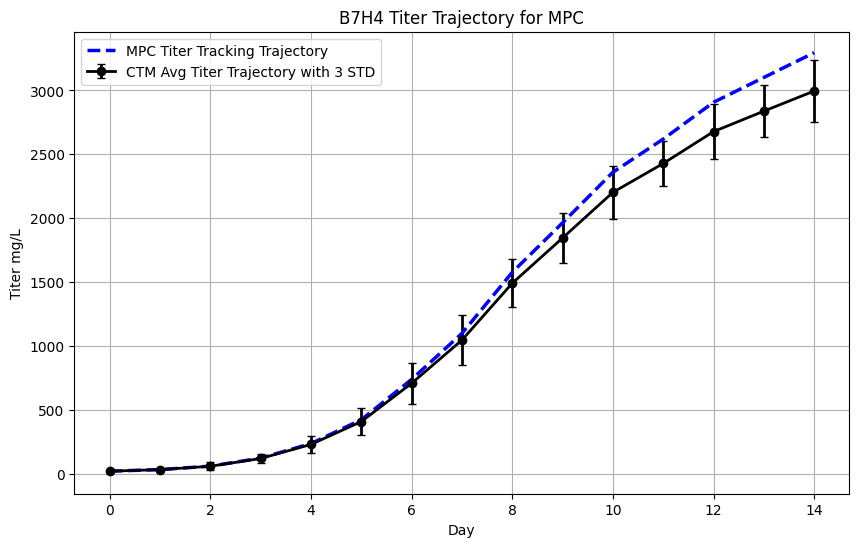

In [9]:
target_increase = 10  # percent increase from mean
trajectory_discount = np.linspace(1.0, 1 + (target_increase / 100), len(df_agg["Day"]))
proposed_trajectory = df_agg["mean"].values * trajectory_discount

plt.figure(figsize=(10, 6))
plt.errorbar(
    df_agg["Day"],
    df_agg["mean"],
    df_agg["std"] * 3,
    fmt="ko-",
    capsize=3,
    label="CTM Avg Titer Trajectory with 3 STD",
    linewidth=2,
)
plt.plot(
    df_agg["Day"],
    proposed_trajectory,
    "b--",
    label="MPC Titer Tracking Trajectory",
    linewidth=2.5,
)
plt.ylabel("Titer mg/L")
plt.xlabel("Day")
plt.title("B7H4 Titer Trajectory for MPC")
plt.grid()
plt.legend()
pd.Series(proposed_trajectory).to_clipboard()

C:\Users\zah48132\AppData\Local\Temp\ipykernel_8848\22509074.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


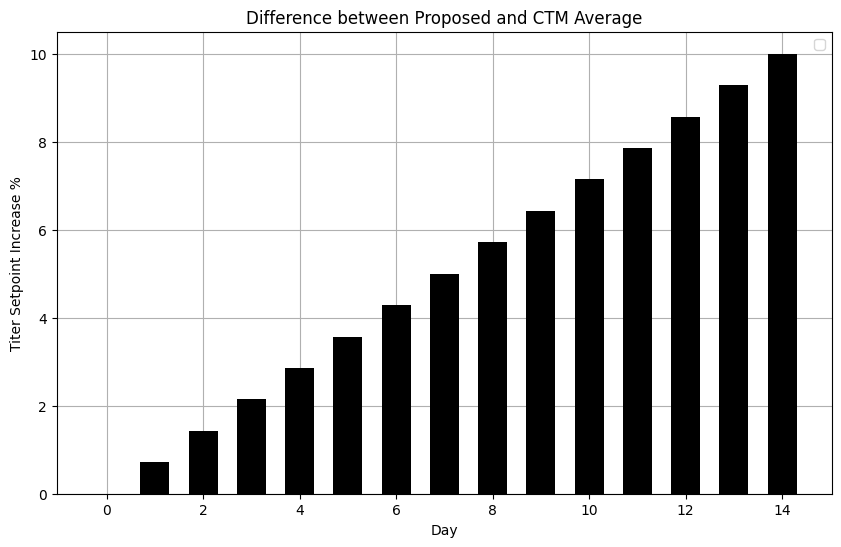

In [39]:
plt.figure(figsize=(10, 6))
plt.bar(
    df_agg["Day"],
    100*(proposed_trajectory-df_agg["mean"])/df_agg["mean"],
    color="k",
    width=0.6,
    # align="edge",
    zorder=2
)
plt.ylabel("Titer Setpoint Increase %")
plt.xlabel("Day")
plt.title("Difference between Proposed and CTM Average")
plt.grid(zorder=1)
plt.legend()